# Kaczmarz Algorithm: Iterative Projections for Linear Systems

## Overview

The **Kaczmarz algorithm** solves a system of linear equations $Ax = b$ by iteratively
projecting the current iterate onto successive hyperplanes defined by each equation.
Originally proposed by Stefan Kaczmarz in 1937, it was independently rediscovered in
medical imaging as the *Algebraic Reconstruction Technique* (ART) and later sparked renewed
interest through the **randomized Kaczmarz** variant of Strohmer and Vershynin (2009).

### Why the Kaczmarz Algorithm Matters

- It is **matrix-free**: each step requires only a dot product and a rank-1 update —
  ideal for sparse or structured systems where storing $A^T A$ is prohibitive.
- It is the discrete analog of the **alternating projection** method in functional analysis.
- The **randomized** variant has guaranteed linear convergence regardless of $m > n$,
  with a rate governed by the condition number.
- It underlies many algorithms in CT reconstruction, signal recovery, and distributed optimization.

### What This Notebook Demonstrates

1. Geometric interpretation: each row $a_i^T x = b_i$ defines a hyperplane; Kaczmarz
   projects orthogonally onto each in turn.
2. Cyclic Kaczmarz vs. Randomized Kaczmarz — residual convergence comparison.
3. Visualization of the iterate trajectory in $\mathbb{R}^2$ (two-equation system).
4. Residual norm $\|Ax^{(k)} - b\|_2$ as a function of sweep count.
5. Comparison with the exact least-squares solution $x^* = A^\dagger b$.

### Mathematical Setup

Consider $Ax = b$ with $A \in \mathbb{R}^{m \times n}$ ($m \geq n$, full column rank).
Row $i$ defines the hyperplane

$$
H_i = \{x \in \mathbb{R}^n : a_i^T x = b_i\}.
$$

The orthogonal projection onto $H_i$ is

$$
\Pi_{H_i}(x) = x - \frac{a_i^T x - b_i}{\|a_i\|^2}\, a_i.
$$

**Cyclic Kaczmarz** cycles through rows $i = 1, 2, \ldots, m, 1, 2, \ldots$

**Randomized Kaczmarz** selects row $i$ at random with probability proportional to $\|a_i\|^2$:

$$
P(\text{select row } i) = \frac{\|a_i\|^2}{\|A\|_F^2}.
$$

### Convergence

For randomized Kaczmarz with consistent $b$, Strohmer and Vershynin (2009) proved

$$
\mathbb{E}\bigl[\|x^{(k)} - x^*\|^2\bigr] \leq \left(1 - \frac{\sigma_{\min}^2(A)}{\|A\|_F^2}\right)^k \|x^{(0)} - x^*\|^2,
$$

where $\sigma_{\min}(A)$ is the smallest singular value of $A$.

### Setup and Imports

We import standard numerical libraries. The two Kaczmarz variants are implemented as
pure NumPy loops for clarity; each step is a single projection:

$$
x \leftarrow x - \frac{a_i^T x - b_i}{\|a_i\|^2}\, a_i.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rng = np.random.default_rng(0)

def cyclic_kaczmarz(A, b, x0, n_sweeps):
    """Cyclic Kaczmarz: one sweep = one pass through all rows."""
    m, n = A.shape
    x = x0.copy().astype(float)
    row_norms_sq = np.sum(A**2, axis=1)  # ||a_i||^2
    history = [x.copy()]
    for _ in range(n_sweeps):
        for i in range(m):
            x -= (A[i] @ x - b[i]) / row_norms_sq[i] * A[i]
        history.append(x.copy())
    return np.array(history)

def randomized_kaczmarz(A, b, x0, n_steps):
    """Randomized Kaczmarz: rows selected with prob ∝ ||a_i||^2."""
    m, n = A.shape
    x = x0.copy().astype(float)
    row_norms_sq = np.sum(A**2, axis=1)
    probs = row_norms_sq / row_norms_sq.sum()
    history = [x.copy()]
    for _ in range(n_steps):
        i = rng.choice(m, p=probs)
        x -= (A[i] @ x - b[i]) / row_norms_sq[i] * A[i]
        history.append(x.copy())
    return np.array(history)

print('Kaczmarz implementations ready.')

Kaczmarz implementations ready.


### 2D Geometric Visualization

With $n = 2$ unknowns and $m = 3$ equations, each row defines a line
$a_i^T x = b_i$ in $\mathbb{R}^2$.
The Kaczmarz iterate zig-zags between these lines, projecting
orthogonally onto each in turn.
For a consistent system the iterates converge to the unique intersection point $x^*$.
For an inconsistent overdetermined system they converge to a cycle near the least-squares solution.

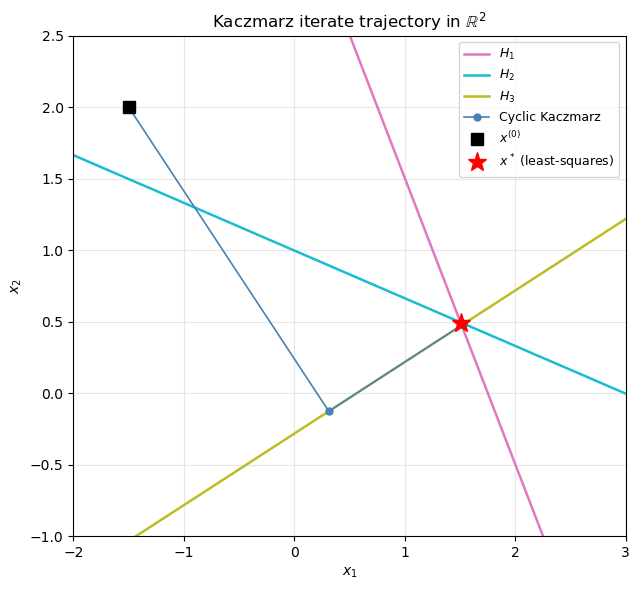

In [2]:
# Small consistent 2x2 system embedded in 3 equations (m=3, n=2)
A2 = np.array([[2.0, 1.0],
               [1.0, 3.0],
               [0.5, -1.0]])
x_true_2d = np.array([1.5, 0.5])
b2 = A2 @ x_true_2d + rng.normal(0, 0.05, 3)  # slightly noisy

x0_2d = np.array([-1.5, 2.0])
n_sweeps_2d = 6

hist_cyc2 = cyclic_kaczmarz(A2, b2, x0_2d, n_sweeps=n_sweeps_2d)
x_ls_2d = np.linalg.lstsq(A2, b2, rcond=None)[0]

t_line = np.linspace(-2.5, 3.5, 200)
colors_lines = ['#e377c2', '#17becf', '#bcbd22']

fig, ax = plt.subplots(figsize=(6.5, 6))

# Draw hyperplanes (lines in 2D)
for i, (a_row, bi, col) in enumerate(zip(A2, b2, colors_lines)):
    # a_row[0]*x + a_row[1]*y = bi  =>  y = (bi - a_row[0]*t) / a_row[1]
    if abs(a_row[1]) > 1e-10:
        y_line = (bi - a_row[0]*t_line) / a_row[1]
    else:
        y_line = np.full_like(t_line, bi / a_row[0])
    ax.plot(t_line, y_line, color=col, lw=1.8, label=f'$H_{i+1}$', zorder=2)

# Trajectory
ax.plot(hist_cyc2[:, 0], hist_cyc2[:, 1], 'o-', color='steelblue',
        markersize=5, lw=1.2, label='Cyclic Kaczmarz', zorder=4)
ax.plot(*hist_cyc2[0], 'ks', markersize=8, label='$x^{(0)}$', zorder=5)
ax.plot(*x_ls_2d, 'r*', markersize=14, label='$x^*$ (least-squares)', zorder=6)

ax.set_xlim(-2, 3); ax.set_ylim(-1, 2.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Kaczmarz iterate trajectory in $\\mathbb{R}^2$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kaczmarz_2d_trajectory.png', dpi=90, bbox_inches='tight')
plt.show()

### Convergence Comparison: Cyclic vs. Randomized

We now create a larger overdetermined system ($m = 40$, $n = 10$) and compare the
residual norm $\|Ax^{(k)} - b\|_2$ for both variants over a fixed budget of steps.

For cyclic Kaczmarz the x-axis counts *sweeps* (one full pass through all rows);
for randomized Kaczmarz we scale to the equivalent number of sweeps
(total steps divided by $m$) so the budgets are comparable.

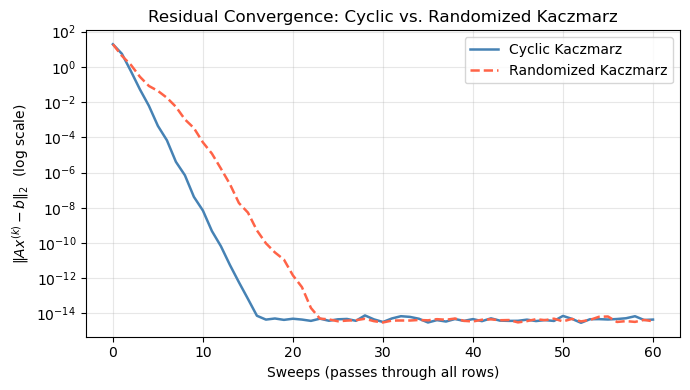

Least-squares solution error (cyclic, final):     7.16e-15
Least-squares solution error (randomized, final): 7.66e-15


In [3]:
m_big, n_big = 40, 10
A_big = rng.standard_normal((m_big, n_big))
x_true_big = rng.standard_normal(n_big)
b_big = A_big @ x_true_big  # consistent system
x0_big = np.zeros(n_big)

n_sweeps_big = 60
n_steps_rand = n_sweeps_big * m_big  # same total projection ops

hist_cyc  = cyclic_kaczmarz(A_big, b_big, x0_big, n_sweeps=n_sweeps_big)
hist_rand = randomized_kaczmarz(A_big, b_big, x0_big, n_steps=n_steps_rand)

x_ls_big = np.linalg.lstsq(A_big, b_big, rcond=None)[0]

# Residuals per sweep
res_cyc = np.linalg.norm(hist_cyc @ A_big.T - b_big, axis=1)  # shape (n_sweeps+1,)
# Sample randomized residuals at every m_big steps
res_rand_sampled = np.linalg.norm(
    hist_rand[::m_big] @ A_big.T - b_big, axis=1)

sweeps = np.arange(len(res_cyc))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(sweeps, res_cyc, label='Cyclic Kaczmarz', color='steelblue', lw=1.8)
ax.semilogy(np.arange(len(res_rand_sampled)), res_rand_sampled,
            label='Randomized Kaczmarz', color='tomato', lw=1.8, linestyle='--')
ax.set_xlabel('Sweeps (passes through all rows)')
ax.set_ylabel('$\\|Ax^{(k)} - b\\|_2$  (log scale)')
ax.set_title('Residual Convergence: Cyclic vs. Randomized Kaczmarz')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('kaczmarz_convergence.png', dpi=90, bbox_inches='tight')
plt.show()

print(f'Least-squares solution error (cyclic, final):     {np.linalg.norm(hist_cyc[-1] - x_ls_big):.2e}')
print(f'Least-squares solution error (randomized, final): {np.linalg.norm(hist_rand[-1] - x_ls_big):.2e}')

### Effect of Condition Number

Convergence speed of Kaczmarz depends on the ratio

$$
\rho = 1 - \frac{\sigma_{\min}^2(A)}{\|A\|_F^2} \in [0,1).
$$

A high condition number $\kappa(A) = \sigma_{\max}/\sigma_{\min}$ makes $\sigma_{\min}$
small and slows convergence.
We generate systems with varying condition numbers by scaling singular values,
and compare residual decay rates.

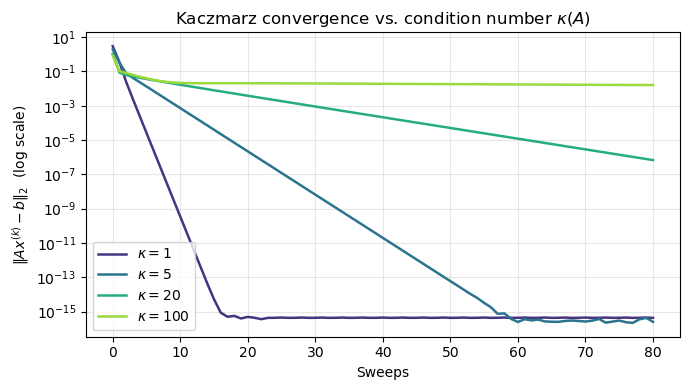

In [4]:
def make_system_cond(m, n, cond, rng):
    """Random system with prescribed condition number."""
    U, _, Vt = np.linalg.svd(rng.standard_normal((m, n)), full_matrices=False)
    sigma = np.logspace(0, -np.log10(cond), n)
    A = U * sigma @ Vt
    x_true = rng.standard_normal(n)
    b = A @ x_true
    return A, b, x_true

conditions = [1, 5, 20, 100]
n_sw = 80
m_c, n_c = 30, 8

fig, ax = plt.subplots(figsize=(7, 4))
palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(conditions)))

for cond, color in zip(conditions, palette):
    A_c, b_c, _ = make_system_cond(m_c, n_c, cond, rng)
    h = cyclic_kaczmarz(A_c, b_c, np.zeros(n_c), n_sweeps=n_sw)
    res = np.linalg.norm(h @ A_c.T - b_c, axis=1)
    ax.semilogy(res, label=f'$\\kappa={cond}$', color=color, lw=1.8)

ax.set_xlabel('Sweeps')
ax.set_ylabel('$\\|Ax^{(k)} - b\\|_2$  (log scale)')
ax.set_title('Kaczmarz convergence vs. condition number $\\kappa(A)$')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('kaczmarz_condnum.png', dpi=90, bbox_inches='tight')
plt.show()

### Static Snapshot

This cell generates `snippet.png` for the repository gallery.
It combines the 2D trajectory view and the residual convergence plot side by side.

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    import numpy as _np

    _rng = _np.random.default_rng(0)
    _A2 = _np.array([[2.,1.],[1.,3.],[.5,-1.]])
    _xt = _np.array([1.5, 0.5])
    _b2 = _A2 @ _xt + _rng.normal(0, .05, 3)
    _x0 = _np.array([-1.5, 2.0])

    def _cyc(A, b, x0, ns):
        x = x0.copy().astype(float)
        rns = _np.sum(A**2, axis=1)
        h = [x.copy()]
        for _ in range(ns):
            for i in range(len(b)):
                x -= (A[i]@x - b[i])/rns[i]*A[i]
            h.append(x.copy())
        return _np.array(h)

    _h2 = _cyc(_A2, _b2, _x0, 6)
    _xls = _np.linalg.lstsq(_A2, _b2, rcond=None)[0]

    _mb, _nb = 40, 10
    _Ab = _rng.standard_normal((_mb, _nb))
    _xb = _rng.standard_normal(_nb)
    _bb = _Ab @ _xb
    _hc = _cyc(_Ab, _bb, _np.zeros(_nb), 40)
    _rc = _np.linalg.norm(_hc @ _Ab.T - _bb, axis=1)

    _fig, (_ax1, _ax2) = _plt.subplots(1, 2, figsize=(8, 4))

    _tl = _np.linspace(-2.5, 3.5, 200)
    for _i, (_a, _bi, _col) in enumerate(zip(_A2, _b2, ['#e377c2','#17becf','#bcbd22'])):
        if abs(_a[1]) > 1e-10:
            _ax1.plot(_tl, (_bi - _a[0]*_tl)/_a[1], color=_col, lw=1.5)
    _ax1.plot(_h2[:,0], _h2[:,1], 'o-', color='steelblue', markersize=4, lw=1.2)
    _ax1.plot(*_h2[0], 'ks', markersize=7)
    _ax1.plot(*_xls, 'r*', markersize=12)
    _ax1.set_xlim(-2, 3); _ax1.set_ylim(-1, 2.5)
    _ax1.set_title('Iterate Trajectory', fontsize=10)
    _ax1.grid(True, alpha=.3)

    _ax2.semilogy(_rc, color='steelblue', lw=1.8)
    _ax2.set_xlabel('Sweeps'); _ax2.set_ylabel('Residual')
    _ax2.set_title('Residual Convergence', fontsize=10)
    _ax2.grid(True, which='both', alpha=.3)

    _fig.suptitle('Kaczmarz Algorithm', fontsize=12)
    _plt.tight_layout()
    _plt.savefig('snippet.png', dpi=100, bbox_inches='tight')
    _plt.close(_fig)
    print('snippet.png saved.')

snippet.png saved.


### Interactive: Observe Convergence Step by Step

Use the slider to step through Kaczmarz sweeps on the 2D system.
Watch how the iterate zigzags between hyperplanes, converging to the least-squares solution.

## Takeaways

- The Kaczmarz algorithm reduces solving $Ax=b$ to a sequence of cheap orthogonal projections,
  each requiring $\mathcal{O}(n)$ arithmetic.
- **Cyclic Kaczmarz** can have oscillatory convergence; **randomized Kaczmarz** has provably
  monotone *expected* residual decay.
- The convergence rate depends critically on the condition number $\kappa(A)$:
  ill-conditioned systems converge much more slowly.
- For inconsistent systems ($b \notin \text{range}(A)$), the iterates cycle near
  the least-squares solution $A^\dagger b$ rather than converging exactly.
- **Block Kaczmarz** and **SART** (Simultaneous Algebraic Reconstruction Technique)
  extend the algorithm to mini-batches of rows, balancing cost per step and convergence speed.

## Bibliography

- S. Kaczmarz, *Angenaherte Auflosung von Systemen linearer Gleichungen*, Bulletin
  International de l'Academie Polonaise des Sciences et des Lettres, 1937.
- T. Strohmer and R. Vershynin, *A Randomized Kaczmarz Algorithm with Exponential Convergence*,
  Journal of Fourier Analysis and Applications, 2009.
- D. Needell and J. Tropp, *Paved with Good Intentions: Analysis of a Randomized Block
  Kaczmarz Method*, Linear Algebra and its Applications, 2014.